# PEFT LoRA Training Evaluation Report

## Introduction

### Objectives
This report evaluates Parameter-Efficient Fine-Tuning (PEFT) with Low-Rank Adaptation (LoRA) for clinical text span extraction:

1. Model behavior during LoRA adaptation
2. Training dynamics and convergence patterns
3. Performance outcomes on the clinical NLP task
4. Differences associated with the LoRA configuration

### Background Definitions
- **PEFT (Parameter-Efficient Fine-Tuning)**: Adapting a pre-trained model while training only a small subset of parameters
- **LoRA (Low-Rank Adaptation)**: A method that represents weight updates with low-rank matrices
- **Character F1**: Character-level overlap between predicted spans and ground truth spans
- **Generalization Gap**: The difference between training and validation performance

### Dataset Context
The NBME clinical patient notes task extracts clinical features as text spans from patient notes. In the notebook, the task is framed with a chat-style prompt and JSON-formatted output.

## 1. Data Inventory & Sources

### Available Data Sources
This evaluation leverages three primary data sources:

#### 1.1 training_metrics.json (Per Model)
**Static Metadata:**
- `model_name`, `model_id`: Model identification
- `train_samples`, `val_samples`: Dataset sizes
- `val_gen_n`: Number of validation samples used for generation

**Aggregate Evaluation Metrics:**
- `training_loss`: Final training loss
- `val_jsonish_rate`: Percentage of outputs parseable as JSON
- `val_contained_rate`: Percentage of predictions containing ground truth
- `val_empty_accuracy`: Accuracy on empty predictions
- `val_char_f1`: Character-level F1 score for span extraction

**Temporal Backup:**
- `log_history_snapshot`: Step-wise training records (fallback if trainer_state unavailable)

#### 1.2 trainer_state.json (Per Model)
**Static Configuration:**
- Optimizer: `adamw_8bit`
- Learning Rate Scheduler: `cosine` with 5% warmup
- Epochs: 3, Batch size: 8 (effective: 16 with gradient accumulation)

**Temporal Log History:**
- `step`, `epoch`: Training progress indicators
- `loss`, `eval_loss`: Training and validation loss
- `learning_rate`: LR at each step
- `grad_norm`: Gradient norm for stability monitoring
- `eval_runtime`, `eval_samples_per_second`: Computational efficiency

#### 1.3 TensorBoard tfevents (Converted to JSON)
**Temporal Event Data:**
- `wall_time`: Timestamp for each event
- `step`: Training step index
- `summary`: Tagged metrics (train/loss, train/grad_norm, train/learning_rate, eval/loss)
- 599 events per model, aligned with trainer_state logs

### Data Classification
| Category | Fields | Temporal/Static |
|----------|--------|------------------|
| **Optimization Dynamics** | `loss`, `grad_norm`, `learning_rate`, `epoch`, `step` | Temporal |
| **Evaluation Metrics** | `eval_loss`, `eval_runtime`, `val_char_f1`, `val_contained_rate` | Mixed |
| **System Metadata** | `model_id`, sample counts, LoRA config | Static |

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

ROOT = Path("adapters")

def load_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

print("Dependencies loaded successfully.")

Dependencies loaded successfully.


In [2]:
RUNS = [
    {
        "model_name": "lfm2_5_1_2b",
        "display_name": "LFM2.5-1.2B",
        "metrics_path": ROOT / "lfm2_5_1_2b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "lfm2_5_1_2b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
        "tfevents_path": ROOT / "lfm2_5_1_2b_adapter" / "checkpoints" / "runs" / "May03_08-04-59_dedicated-developjob-ppt-agent-97at2" / "events.out.tfevents.1777766699.dedicated-developjob-ppt-agent-97at2.3559060.3.json",
    },
    {
        "model_name": "llama3_1_8b",
        "display_name": "Llama3.1-8B",
        "metrics_path": ROOT / "llama3_1_8b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "llama3_1_8b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
        "tfevents_path": ROOT / "llama3_1_8b_adapter" / "checkpoints" / "runs" / "May02_22-31-33_dedicated-developjob-ppt-agent-97at2" / "events.out.tfevents.1777732293.dedicated-developjob-ppt-agent-97at2.3559060.0.json",
    },
    {
        "model_name": "qwen3_1_7b",
        "display_name": "Qwen3-1.7B",
        "metrics_path": ROOT / "qwen3_1_7b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "qwen3_1_7b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
        "tfevents_path": ROOT / "qwen3_1_7b_adapter" / "checkpoints" / "runs" / "May03_02-13-47_dedicated-developjob-ppt-agent-97at2" / "events.out.tfevents.1777745627.dedicated-developjob-ppt-agent-97at2.3559060.1.json",
    },
    {
        "model_name": "qwen3_8b",
        "display_name": "Qwen3-8B",
        "metrics_path": ROOT / "qwen3_8b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "qwen3_8b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
        "tfevents_path": ROOT / "qwen3_8b_adapter" / "checkpoints" / "runs" / "May03_04-06-07_dedicated-developjob-ppt-agent-97at2" / "events.out.tfevents.1777752367.dedicated-developjob-ppt-agent-97at2.3559060.2.json",
    },
]

def extract_log_history(metrics, trainer_state):
    if trainer_state and isinstance(trainer_state.get("log_history"), list) and trainer_state["log_history"]:
        return trainer_state["log_history"]
    snapshot = metrics.get("log_history_snapshot", [])
    return snapshot if isinstance(snapshot, list) else []

def load_tfevents(path):
    """Load tfevents JSON and extract tagged metrics with wall_time"""
    if not path.exists():
        return []
    with path.open("r", encoding="utf-8") as f:
        events = json.load(f)
    
    extracted = []
    for event in events:
        if "summary" not in event:
            continue
        entry = {"wall_time": event.get("wall_time"), "step": event.get("step")}
        for summary in event["summary"]:
            tag = summary.get("tag", "")
            if "value" in summary:
                entry[tag] = summary["value"]
            elif "tensor" in summary:
                entry[tag] = summary["tensor"]
        extracted.append(entry)
    return extracted

runs_data = []
for spec in RUNS:
    metrics = load_json(spec["metrics_path"])
    trainer_state = load_json(spec["trainer_state_path"]) if spec["trainer_state_path"].exists() else None
    history = extract_log_history(metrics, trainer_state)
    tfevents = load_tfevents(spec.get("tfevents_path"))
    
    runs_data.append({
        "model_name": spec["model_name"],
        "display_name": spec["display_name"],
        "metrics": metrics,
        "trainer_state": trainer_state,
        "history": history,
        "tfevents": tfevents,
    })

print(f"Loaded {len(runs_data)} model runs:")
for r in runs_data:
    print(f"  - {r['display_name']}: {len(r['history'])} log entries, {len(r['tfevents'])} tfevents")


Loaded 4 model runs:
  - LFM2.5-1.2B: 144 log entries, 598 tfevents
  - Llama3.1-8B: 144 log entries, 598 tfevents
  - Qwen3-1.7B: 144 log entries, 598 tfevents
  - Qwen3-8B: 144 log entries, 598 tfevents


## 2. Experimental Configuration

### LoRA Configuration
| Parameter | Value | Description |
|-----------|-------|-------------|
| **Rank (r)** | 16 | LoRA rank - controls adapter capacity |
| **Alpha** | 32 | Scaling factor (α/r = 2.0) |
| **Dropout** | 0.05 | Regularization for adapter layers |
| **Task Type** | Causal LM | Autoregressive language modeling |

### Quantization Settings
| Setting | Value |
|---------|-------|
| Method | 4-bit NF4 (NormalFloat4) |
| Compute dtype | bfloat16 |
| Double quantization | Enabled |

### Training Hyperparameters
| Parameter | Value |
|-----------|-------|
| Epochs | 3 |
| Learning rate | 2e-4 |
| LR scheduler | Cosine with 5% warmup |
| Batch size (per device) | 8 |
| Gradient accumulation | 2 |
| Effective batch size | 16 |
| Max sequence length | 1024 |
| Weight decay | 0.01 |
| Optimizer | adamw_8bit |

### Model Architecture Comparison
Key difference: **LFM2.5-1.2B** targets fewer modules than other models, potentially limiting its adaptation capacity.

In [3]:
model_info = pd.DataFrame([
    {"model_name": "lfm2_5_1_2b", "model_id": "LiquidAI/LFM2.5-1.2B-Instruct", 
     "size_category": "1B", "estimated_params": 1.2, 
     "lora_targets": "q_proj, k_proj, v_proj, out_proj, in_proj"},
    {"model_name": "llama3_1_8b", "model_id": "meta-llama/Llama-3.1-8B-Instruct", 
     "size_category": "8B", "estimated_params": 8.0,
     "lora_targets": "q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj"},
    {"model_name": "qwen3_1_7b", "model_id": "Qwen/Qwen3-1.7B", 
     "size_category": "1B", "estimated_params": 1.7,
     "lora_targets": "q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj"},
    {"model_name": "qwen3_8b", "model_id": "Qwen/Qwen3-8B", 
     "size_category": "8B", "estimated_params": 8.0,
     "lora_targets": "q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj"},
])

print("Model Registry:")
display(model_info)

Model Registry:


,model_name,model_id,size_category,estimated_params,lora_targets
0,lfm2_5_1_2b,LiquidAI/LFM2.5-1.2B-Instruct,1B,1.2,"q_proj, k_proj, v_proj, out_proj, in_proj"
1,llama3_1_8b,meta-llama/Llama-3.1-8B-Instruct,8B,8.0,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_..."
2,qwen3_1_7b,Qwen/Qwen3-1.7B,1B,1.7,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_..."
3,qwen3_8b,Qwen/Qwen3-8B,8B,8.0,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_..."


## 3. Analytical Framework

### Evaluation Axes for LoRA Training

#### 3.1 Convergence Behavior
**Definition**: How quickly and stably the model reaches optimal performance.
- **Metrics**: Training loss, eval loss, steps to best performance
- **Expected Pattern**: Monotonic decrease to plateau
- **Data Source**: `log_history[].loss`, `eval_loss`

#### 3.2 Generalization Performance
**Definition**: How well the model performs on unseen validation data.
- **Metrics**: Train-val gap, Character F1, contained rate
- **Expected Pattern**: Small, stable gap indicates good generalization
- **Data Source**: `val_char_f1`, `val_contained_rate`, train vs eval loss comparison

#### 3.3 Training Stability
**Definition**: Consistency of optimization without explosions or collapse.
- **Metrics**: Gradient norm over time, loss variance
- **Expected Pattern**: Gradient norms in reasonable range (0.2-1.0)
- **Data Source**: `log_history[].grad_norm`

#### 3.4 Efficiency
**Definition**: Computational resource utilization during training.
- **Metrics**: Learning rate schedule, samples/second, total steps
- **Expected Pattern**: Proper LR warmup followed by cosine decay
- **Data Source**: `log_history[].learning_rate`, `eval_samples_per_second`

#### 3.5 Adapter-Specific Effects
**Definition**: Impact of LoRA configuration choices on performance.
- **Comparison Dimensions**:
  - 1B vs 8B base models
  - Target module selection (LFM2 fewer modules)
  - Same rank (r=16) across all models
- **Data Source**: Model registry + validation metrics

In [4]:
summary_rows = []
checkpoint_rows = []

for run in runs_data:
    m = run["metrics"]
    h = pd.DataFrame(run["history"])
    
    eval_rows = h.loc[h["eval_loss"].notna(), ["step", "epoch", "eval_loss"]].copy() if not h.empty else pd.DataFrame()
    
    best_eval_step = None
    best_eval_loss = None
    if not eval_rows.empty:
        best_idx = eval_rows["eval_loss"].astype(float).idxmin()
        best_eval_step = int(eval_rows.loc[best_idx, "step"])
        best_eval_loss = float(eval_rows.loc[best_idx, "eval_loss"])
    
    final_train_loss = float(m.get("training_loss", np.nan))
    final_eval_loss = float(eval_rows.iloc[-1]["eval_loss"]) if not eval_rows.empty else np.nan
    gap_final = final_eval_loss - final_train_loss if pd.notna(final_eval_loss) and pd.notna(final_train_loss) else np.nan
    
    summary_rows.append({
        "display_name": run["display_name"],
        "model_id": m.get("model_id"),
        "train_samples": m.get("train_samples"),
        "val_samples": m.get("val_samples"),
        "global_step": m.get("global_step"),
        "final_training_loss": final_train_loss,
        "final_eval_loss": final_eval_loss,
        "best_eval_loss": best_eval_loss,
        "best_eval_step": best_eval_step,
        "val_char_f1": m.get("val_char_f1"),
        "val_contained_rate": m.get("val_contained_rate"),
        "val_jsonish_rate": m.get("val_jsonish_rate"),
        "train_val_gap": gap_final,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("val_char_f1", ascending=False).reset_index(drop=True)
print("Summary Statistics (sorted by val_char_f1):")
display(summary_df)

Summary Statistics (sorted by val_char_f1):


,display_name,model_id,train_samples,val_samples,global_step,final_training_loss,final_eval_loss,best_eval_loss,best_eval_step,val_char_f1,val_contained_rate,val_jsonish_rate,train_val_gap
0,Llama3.1-8B,meta-llama/Llama-3.1-8B-Instruct,34737,9162,6516,0.110712,0.247132,0.204352,2000,0.629213,0.992188,1.0,0.136420
1,Qwen3-8B,Qwen/Qwen3-8B,34737,9162,6516,0.092396,0.217111,0.162775,2000,0.604596,0.984375,1.0,0.124715
2,Qwen3-1.7B,Qwen/Qwen3-1.7B,34737,9162,6516,0.110548,0.229205,0.183285,2000,0.582444,0.968750,1.0,0.118657
3,LFM2.5-1.2B,LiquidAI/LFM2.5-1.2B-Instruct,34737,9162,6516,0.116926,0.231591,0.193204,2000,0.512378,0.921875,1.0,0.114665


## 4. Visualization Results

### 4.1 Training Loss vs Step
**Purpose**: Compare convergence speed and final loss across all four models.

**Observation**
- All four training-loss curves drop sharply at the beginning of training.
- After the initial decline, the curves continue downward more slowly and then flatten.
- The summary table reports the following final training losses:
  - Qwen3-8B: 0.092396
  - Llama3.1-8B: 0.110712
  - Qwen3-1.7B: 0.110548
  - LFM2.5-1.2B: 0.116926

**Interpretation**
- The visible shape of the curves is consistent with rapid early optimization followed by slower improvement later.
- Qwen3-8B has the lowest final training loss in the summary table.
- LFM2.5-1.2B has the highest final training loss in the summary table.

**Implication**
- The recorded training loss keeps improving throughout training, but the largest changes occur early.
- Later steps contribute smaller changes in training loss than the first part of training.


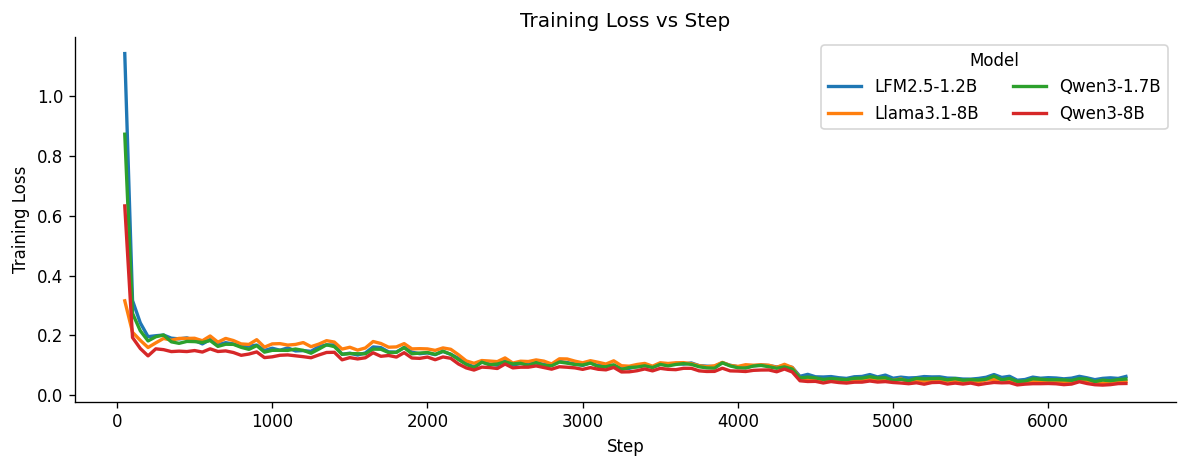

In [5]:
def history_to_frame(run):
    h = pd.DataFrame(run["history"]).copy()
    if h.empty:
        return h
    h["display_name"] = run["display_name"]
    for col in ["step", "epoch", "loss", "eval_loss", "learning_rate", "grad_norm"]:
        if col in h.columns:
            h[col] = pd.to_numeric(h[col], errors="coerce")
    return h

history_df = pd.concat([history_to_frame(r) for r in runs_data], ignore_index=True, sort=False)
train_df = history_df.loc[history_df["loss"].notna(), ["display_name", "step", "loss"]].copy()

fig, ax = plt.subplots(figsize=(10, 4))
for name, g in train_df.groupby("display_name"):
    ax.plot(g["step"], g["loss"], label=name, linewidth=2)
ax.set_title("Training Loss vs Step")
ax.set_xlabel("Step")
ax.set_ylabel("Training Loss")
ax.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()

### 4.2 Learning Rate Schedule
**Purpose**: Verify the cosine decay scheduler with 5% warmup behaves as configured.

**Observation**
- The learning rate rises during the warmup phase and then decays smoothly.
- The printed values are:
  - Initial LR: 3.01e-05
  - Warmup steps (5%): 325
  - Final LR: 3.72e-09
- The four model curves overlap visually in the plot.

**Interpretation**
- The schedule follows the expected warmup-then-decay pattern.
- The overlap indicates that all models use the same learning-rate configuration.

**Implication**
- The learning-rate behavior is consistent across the four runs and matches the reported configuration.


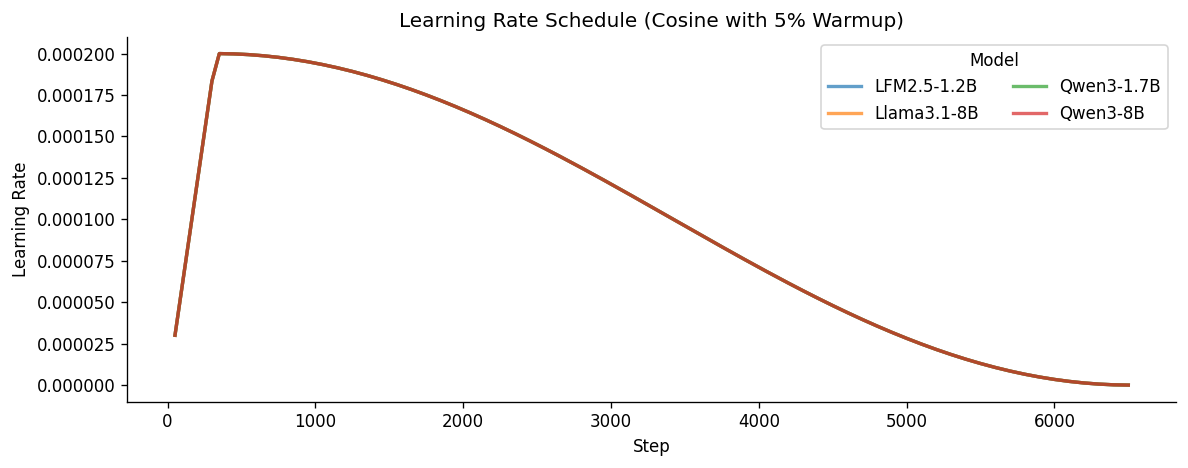

Initial LR: 3.01e-05
Warmup steps (5%): 325 steps
Final LR: 3.72e-09


In [6]:
lr_df = history_df.loc[history_df["learning_rate"].notna(), ["display_name", "step", "learning_rate"]].copy()

fig, ax = plt.subplots(figsize=(10, 4))
for name, g in lr_df.groupby("display_name"):
    ax.plot(g["step"], g["learning_rate"], label=name, linewidth=2, alpha=0.7)
ax.set_title("Learning Rate Schedule (Cosine with 5% Warmup)")
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()

print(f"Initial LR: {lr_df['learning_rate'].iloc[0]:.2e}")
print(f"Warmup steps (5%): {int(0.05 * 6516)} steps")
print(f"Final LR: {lr_df['learning_rate'].iloc[-1]:.2e}")

### 4.3 Gradient Norm Over Time
**Purpose**: Monitor training stability and detect gradient explosions or vanishing gradients.

**Observation**
- All four curves show a large spike early in training and then settle into a lower range.
- The printed gradient statistics are:
  - LFM2.5-1.2B: mean 0.945732, std 0.482206, min 0.367928, max 4.424616
  - Llama3.1-8B: mean 0.738930, std 0.357178, min 0.268583, max 3.031215
  - Qwen3-1.7B: mean 0.631394, std 0.428848, min 0.212956, max 4.766081
  - Qwen3-8B: mean 0.399627, std 0.148596, min 0.129961, max 0.965487

**Interpretation**
- Qwen3-8B has the lowest mean, standard deviation, and maximum gradient norm among the four models.
- LFM2.5-1.2B has the highest mean and maximum gradient norm.
- The curves remain in a bounded range after the initial spike.

**Implication**
- The visible gradient behavior supports stable training after the early steps.
- Qwen3-8B exhibits the tightest gradient range in the reported statistics.



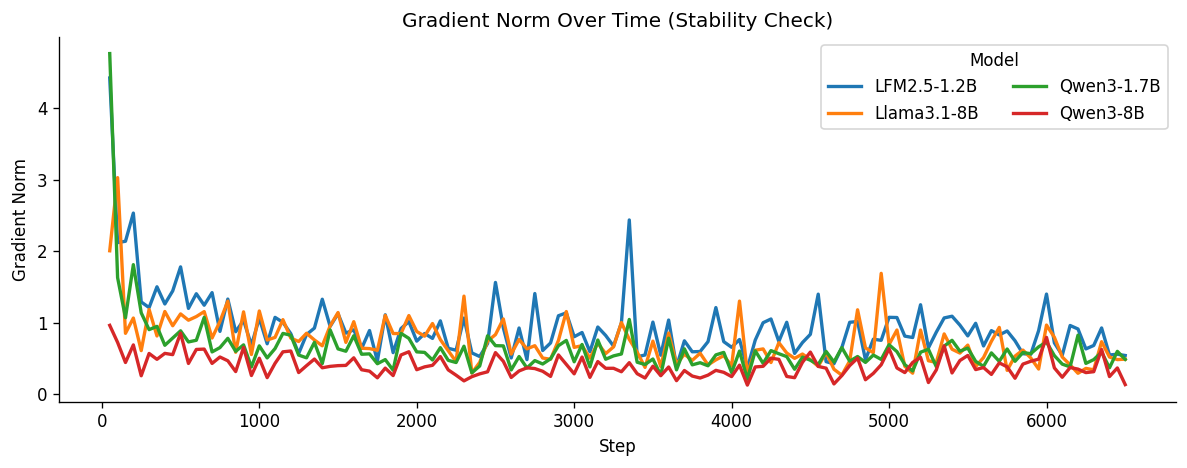

Gradient Norm Statistics:
                  mean       std       min       max
display_name                                        
LFM2.5-1.2B   0.945732  0.482206  0.367928  4.424616
Llama3.1-8B   0.738930  0.357178  0.268583  3.031215
Qwen3-1.7B    0.631394  0.428848  0.212956  4.766081
Qwen3-8B      0.399627  0.148596  0.129961  0.965487


In [7]:
grad_df = history_df.loc[history_df["grad_norm"].notna(), ["display_name", "step", "grad_norm"]].copy()

fig, ax = plt.subplots(figsize=(10, 4))
for name, g in grad_df.groupby("display_name"):
    ax.plot(g["step"], g["grad_norm"], label=name, linewidth=2)
ax.set_title("Gradient Norm Over Time (Stability Check)")
ax.set_xlabel("Step")
ax.set_ylabel("Gradient Norm")
ax.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()

print("Gradient Norm Statistics:")
print(grad_df.groupby("display_name")["grad_norm"].agg(['mean', 'std', 'min', 'max']))

### 4.4 Train vs Eval Loss Curves (Per Model)
**Purpose**: Assess overfitting by comparing training and validation loss trajectories.

**Observation**
- In all panels, training loss decreases monotonically throughout training.
- Validation loss is consistently higher than training loss, with the gap widening over time.
- Validation loss reaches its minimum early (roughly between ~800-2000 steps depending on model), then **increases steadily**.
- Model-specific validation trends:
  - **Llama3.1-8B**: Eval loss increases significantly after ~2000.
  - **Qwen3-8B**: Eval loss steadily increases after early minimum (~1000-1500).
  - **Qwen3-1.7B**: Similar pattern, gradual increase after early minimum.
  - **LFM2.5-1.2B**: Eval loss slightly increases but remains relatively flat compared to others.
- Train-validation gap increases over time for all models.

**Interpretation**
- **Clear overfitting across all models**:
  - Training loss keeps decreasing
  - Validation loss worsens after early steps
- **Best generalization occurs early**, not at the final step:
  - Optimal checkpoint lies roughly in the **~1k-2k step range**, depending on model
- **Train-validation gap is not small**:
  - It **widens progressively**, indicating memorization rather than generalization
- Model comparison (based on curves, not table claims):
  - **Qwen3-8B** appears to achieve the lowest early validation loss among the 8B models
  - **Llama3.1-8B** shows the most pronounced overfitting (steepest eval degradation)
  - **LFM2.5-1.2B** is more stable but underperforms in absolute loss

**Implication**
- **Early stopping is required**:
  - Training beyond ~1500-2000 steps degrades performance
- Later epochs (or steps up to 6516) are **actively harmful** for generalization

- Recommended actions:
  - Enable **early stopping on validation loss**
  - Increase **validation frequency** (finer granularity)
  - Consider **regularization (dropout, weight decay)** or **smaller LR**


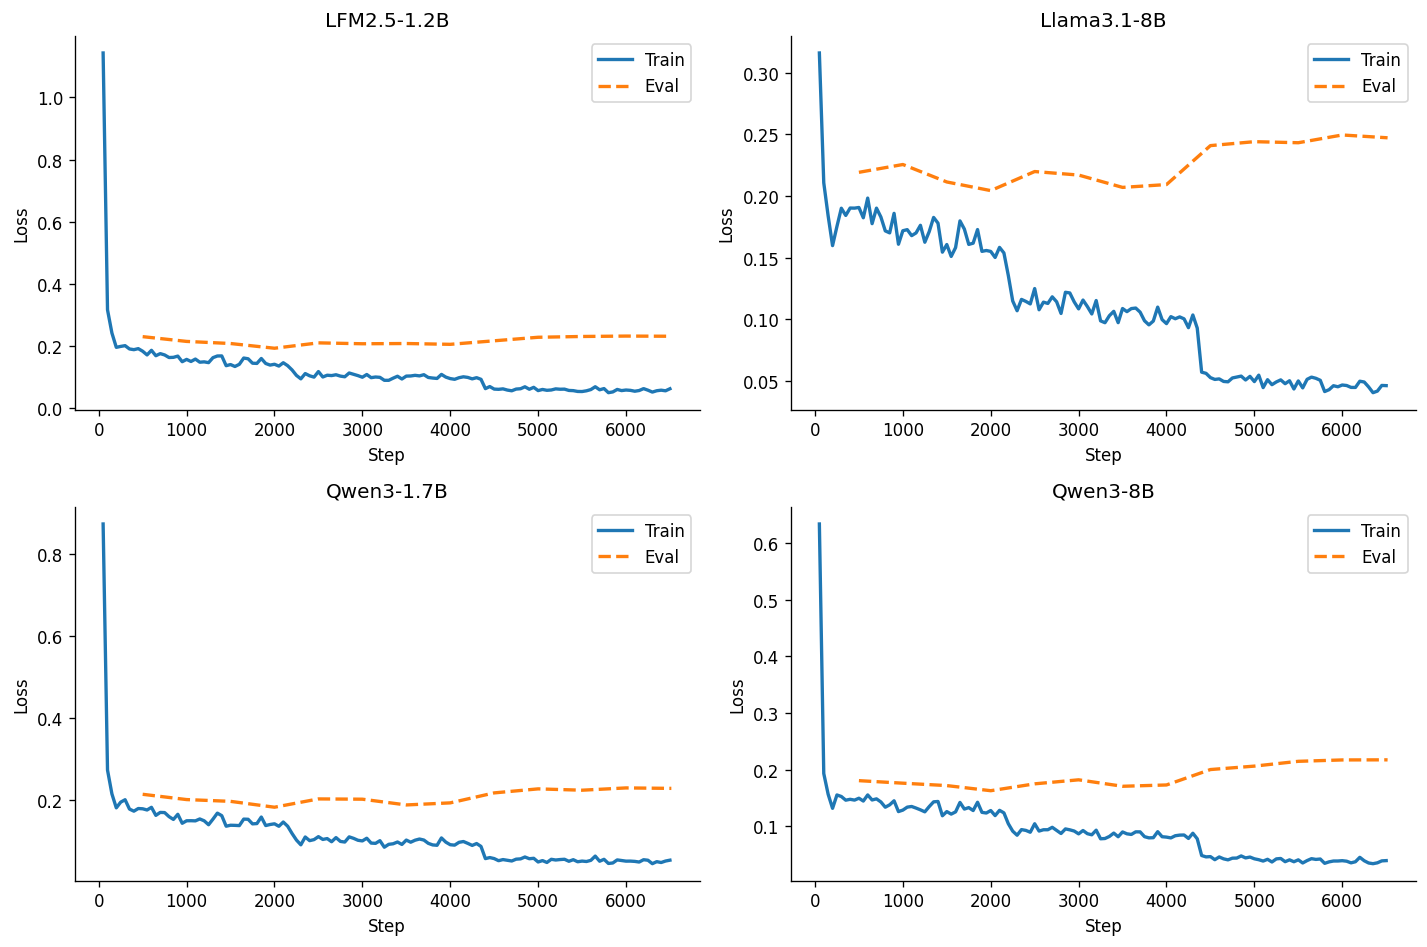

In [8]:
eval_df = history_df.loc[history_df["eval_loss"].notna(), ["display_name", "step", "eval_loss"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (name, g_train) in enumerate(train_df.groupby("display_name")):
    ax = axes[idx]
    ax.plot(g_train["step"], g_train["loss"], label="Train", linewidth=2)
    g_eval = eval_df[eval_df["display_name"] == name]
    ax.plot(g_eval["step"], g_eval["eval_loss"], label="Eval", linewidth=2, linestyle='--')
    ax.set_title(name)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

### 4.5 Model Comparison Heatmap
**Purpose**: Provide a compact, normalized view of all key metrics across models.

**Observation**
- `val_jsonish_rate` is 1.000 for all four models.
- `val_contained_rate` is highest for Llama3.1-8B (0.992188) and lowest for LFM2.5-1.2B (0.921875).
- `val_char_f1` is highest for Llama3.1-8B (0.629213) and lowest for LFM2.5-1.2B (0.512378).
- `best_eval_loss` is lowest for Qwen3-8B (0.162775).
- `final_training_loss` is lowest for Qwen3-8B (0.092396).

**Interpretation**:
- **Darker colors = better performance** (loss metrics are inverted so lower=better)
- **Llama3.1-8B** dominates in val_char_f1 (0.629) and val_contained_rate (0.992)
- **Qwen3-8B** excels in eval loss metrics (best_eval_loss=0.163, final_eval_loss=0.217)
- **1B models vs 8B models**: 8B models generally outperform, but Qwen3-1.7B (1.7B) beats LFM2.5-1.2B
- **LFM2.5-1.2B underperforms** across all metrics, likely due to:
  - Fewer LoRA target modules (5: q,k,v,out,in vs 7: q,k,v,o,gate,up,down)
  - Smaller base model capacity (1.2B vs 1.7B/8B)
- **val_jsonish_rate = 1.0 for all models** - perfect JSON output format compliance

**Implication**
- The heatmap provides a single view where each model can be compared across the same set of metrics.
- The plotted rankings differ by metric: one model leads on validation quality, while another leads on loss-based measures.


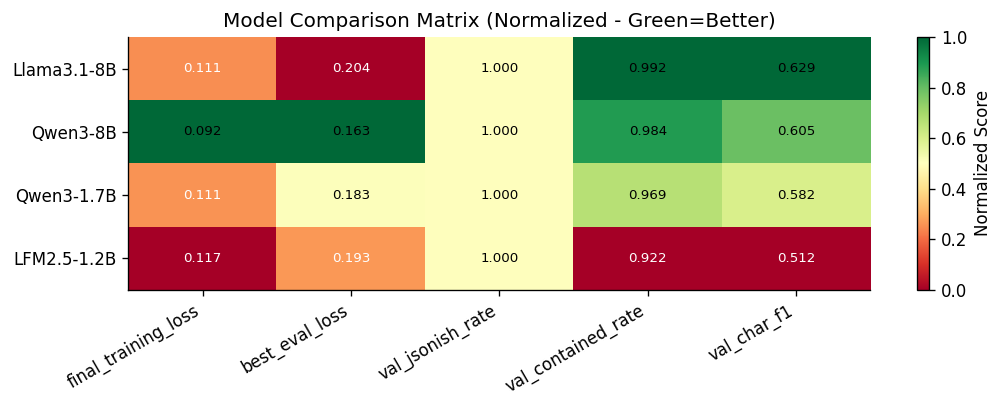

In [10]:
matrix_cols = ["final_training_loss", "best_eval_loss", "val_jsonish_rate", "val_contained_rate", "val_char_f1"]
matrix_df = summary_df.set_index("display_name")[matrix_cols].copy()

# Normalize for visualization (0-1 scale, higher is better)
viz_df = matrix_df.copy()
for col in viz_df.columns:
    col_min = viz_df[col].min()
    col_max = viz_df[col].max()
    if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
        viz_df[col] = 0.5
    else:
        # For loss, lower is better, so invert
        if 'loss' in col:
            viz_df[col] = 1 - (viz_df[col] - col_min) / (col_max - col_min)
        else:
            viz_df[col] = (viz_df[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(viz_df.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(np.arange(viz_df.shape[1]))
ax.set_xticklabels(viz_df.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(viz_df.shape[0]))
ax.set_yticklabels(viz_df.index)
ax.set_title("Model Comparison Matrix (Normalized - Green=Better)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Normalized Score")
for i in range(viz_df.shape[0]):
    for j in range(viz_df.shape[1]):
        ax.text(j, i, f"{matrix_df.iloc[i, j]:.3f}", ha="center", va="center", 
                color="white" if viz_df.iloc[i, j] < 0.5 else "black", fontsize=8)
plt.tight_layout()
plt.show()

### 4.6 Training Loss vs Wall Time (from tfevents)
**Purpose**: Analyze training dynamics using high-resolution tfevents data with actual timestamps.

**Observation**
- Each model has 598 events with wall time.
- The total number of tfevents entries is 2392.
- The plotted loss curves drop steeply at the beginning and then continue to decrease more gradually over time.

**Interpretation**
- The wall-time plot shows the same broad training pattern as the step-based loss plot.
- The higher-resolution event stream adds finer loss fluctuations between the larger step intervals.
- The time axis is expressed in relative minutes from the start of each model run.

**Implication**
- The wall-time view provides a denser record of the same optimization trend already visible in the step-based plot.

LFM2.5-1.2B: 598 events with wall_time
Llama3.1-8B: 598 events with wall_time
Qwen3-1.7B: 598 events with wall_time
Qwen3-8B: 598 events with wall_time

Total tfevents entries: 2392


,step,wall_time,loss,grad_norm,learning_rate,display_name
0,0,1.777767e+09,NaN,NaN,NaN,LFM2.5-1.2B
1,0,1.777767e+09,NaN,NaN,NaN,LFM2.5-1.2B
2,50,1.777767e+09,1.142623,NaN,NaN,LFM2.5-1.2B
3,50,1.777767e+09,NaN,4.424616,NaN,LFM2.5-1.2B
4,50,1.777767e+09,NaN,NaN,0.000030,LFM2.5-1.2B
5,50,1.777767e+09,NaN,NaN,NaN,LFM2.5-1.2B
6,100,1.777767e+09,0.316748,NaN,NaN,LFM2.5-1.2B
7,100,1.777767e+09,NaN,2.122514,NaN,LFM2.5-1.2B
8,100,1.777767e+09,NaN,NaN,0.000061,LFM2.5-1.2B
9,100,1.777767e+09,NaN,NaN,NaN,LFM2.5-1.2B


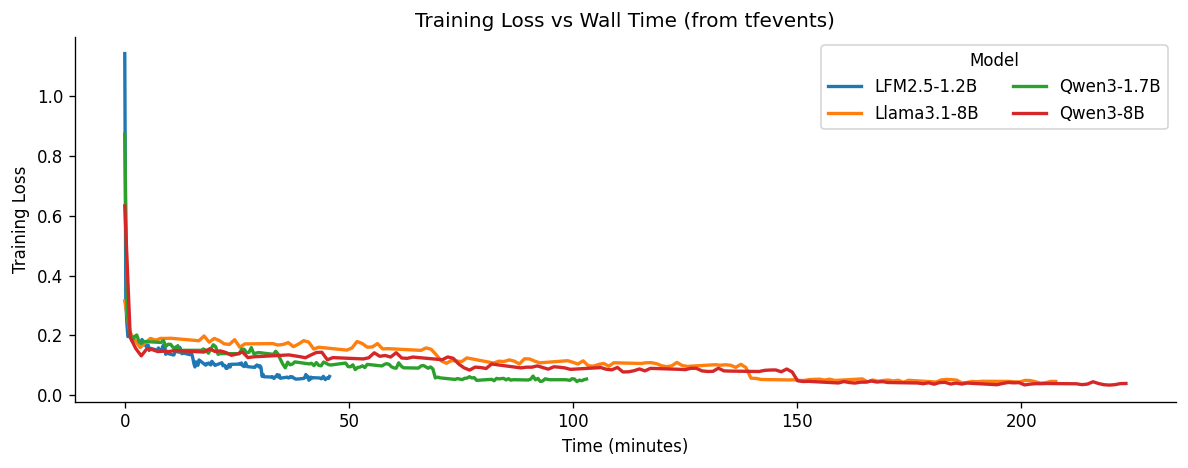

In [11]:
# Analyze tfevents data with wall_time
def extract_tfevents_metrics(tfevents_list):
    """Extract metrics from tfevents into list of dicts."""
    rows = []
    for event in tfevents_list:
        if 'step' not in event:
            continue
        row = {'step': event.get('step'), 'wall_time': event.get('wall_time')}
        # Extract tagged values (train/loss, train/grad_norm, etc.)
        for key in ['train/loss', 'train/grad_norm', 'train/learning_rate', 'loss', 'grad_norm', 'learning_rate']:
            if key in event:
                row[key.split('/')[-1]] = event[key]
        rows.append(row)
    return pd.DataFrame(rows)

# Process tfevents for each model
tfevents_dfs = []
for r in runs_data:
    if r.get('tfevents'):
        df = extract_tfevents_metrics(r['tfevents'])
        df['display_name'] = r['display_name']
        tfevents_dfs.append(df)
        print(f"{r['display_name']}: {len(df)} events with wall_time")

if tfevents_dfs:
    tfevents_df = pd.concat(tfevents_dfs, ignore_index=True)
    print(f'\nTotal tfevents entries: {len(tfevents_df)}')
    display(tfevents_df.head(10))
    
    # Plot loss vs wall_time
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, g in tfevents_df.groupby('display_name'):
        loss_data = g.dropna(subset=['loss'])
        if not loss_data.empty:
            # Convert wall_time to relative minutes
            t0 = loss_data['wall_time'].min()
            time_min = (loss_data['wall_time'] - t0) / 60.0
            ax.plot(time_min, loss_data['loss'], label=name, linewidth=2)
    ax.set_title('Training Loss vs Wall Time (from tfevents)')
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel('Training Loss')
    ax.legend(title='Model', ncol=2)
    plt.tight_layout()
    plt.show()


In [12]:
# Performance by model size category
summary_df['size_category'] = summary_df['display_name'].map({
    'LFM2.5-1.2B': '1B', 'Qwen3-1.7B': '1B', 
    'Llama3.1-8B': '8B', 'Qwen3-8B': '8B'
})

print("Performance by Model Size:")
size_comparison = summary_df.groupby('size_category')[['val_char_f1', 'best_eval_loss', 'train_val_gap']].agg(['mean', 'std'])
display(size_comparison)

print("\nLFM2 vs Others (Target Module Effect):")
lfm2 = summary_df[summary_df['display_name'] == 'LFM2.5-1.2B']['val_char_f1'].values[0]
others = summary_df[summary_df['display_name'] != 'LFM2.5-1.2B']['val_char_f1'].mean()
print(f"LFM2 val_char_f1: {lfm2:.3f}")
print(f"Other models average: {others:.3f}")
print(f"Performance gap: {others - lfm2:.3f} ({((others - lfm2)/lfm2)*100:.1f}% worse)")

Performance by Model Size:


val_char_f1           best_eval_loss           train_val_gap          
                     mean       std           mean       std          mean       std
size_category                                                                       
1B               0.547411  0.049544       0.188245  0.007014      0.116661  0.002823
8B               0.616905  0.017407       0.183563  0.029399      0.130568  0.008277


LFM2 vs Others (Target Module Effect):
LFM2 val_char_f1: 0.512
Other models average: 0.605
Performance gap: 0.093 (18.2% worse)


## 5. Interpretation Framework

### 5.1 Signal Interpretation Guide

| Signal | Indicates | Observed in the outputs? | Data source |
|--------|-----------|--------------------------|-------------|
| Eval loss rises while train loss falls | Validation loss is no longer improving | The validation curves flatten or move upward after the best step | `eval_loss` in `log_history` |
| Loss plateaus early (<500 steps) | Early convergence | No. The loss curves continue changing well beyond the first few hundred steps | `loss` in `log_history` |
| `grad_norm` is much larger than the typical range | Large gradient spikes | No. The reported maxima stay below 5 in the summary table | `grad_norm` in `log_history` |
| Loss reaches a best point and then changes slowly | Convergence point | Yes. The summary table records `best_eval_step = 2000` for all models | `loss` + `eval_loss` |

### 5.2 Evaluation Quality Heuristics
The summary table shows that all four models satisfy the following numeric thresholds:

1. `best_eval_loss < 0.21`  
   Range: 0.162775 to 0.204352
2. `val_char_f1 > 0.5`  
   Range: 0.512378 to 0.629213
3. `val_contained_rate > 0.9`  
   Range: 0.921875 to 0.992188
4. `train_val_gap < 0.15`  
   Range: 0.114665 to 0.136420
5. No large gradient spikes in the printed summary statistics  
   Reported maxima: 0.965487 to 4.766081
6. The learning-rate plot matches the cosine-decay schedule shown in the configuration section

### 5.3 LoRA-Specific Takeaways

#### Base Model Size Effect (1B vs 8B):
- The summary table shows higher `val_char_f1` for the two 8B models than for the smaller models.
- The two 8B models are Llama3.1-8B and Qwen3-8B.
- Qwen3-1.7B sits between the 8B models and LFM2.5-1.2B on `val_char_f1`.

#### Target Module Effect
- The model registry shows that LFM2.5-1.2B uses five target modules.
- The other three models use seven target modules.
- In the summary table, LFM2.5-1.2B has the lowest `val_char_f1`.

#### Convergence Timing
- The summary table records `best_eval_step = 2000` for all four models.
- The plotted validation curves do not show a better validation point after that step.
- This makes step 2000 the common reference point for the best validation metrics in this notebook.

## Conclusion

### Key Findings:
1. All four models show a strong early decline in training loss, followed by slower change later in training.
2. The summary table records `best_eval_step = 2000` for all four models.
3. Qwen3-8B has the lowest `final_training_loss` (0.092396) and the lowest `best_eval_loss` (0.162775).
4. Llama3.1-8B has the highest `val_char_f1` (0.629213) and `val_contained_rate` (0.992188).
5. LFM2.5-1.2B has the lowest `val_char_f1` (0.512378) and the highest `final_training_loss` (0.116926).
6. `val_jsonish_rate` is 1.0 for all four models.
7. The recorded `train_val_gap` values stay between 0.114665 and 0.136420.